In [1]:
from __future__ import annotations

import csv
import logging
import sys
import time

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from torch.amp import GradScaler, autocast
from torch.optim import Adam
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.loader import DataLoader, DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.physics_aware_NN import (
    GNN,
    NN,
    GlobalMLP,
    QuantumCircuitGraphDataset,
    Regressor,
)
from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train import build_loss, train_model
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import (
    collect_files_path,
    evaluate_loss,
    unpack_supervised_batch,
)
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

# Training

In [2]:
class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

In [3]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [4]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

In [5]:
def run_training(
    cfg: TrainConfig,
    model_hparams: dict | None = None,
    train_hparams: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = (
        build_loaders(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
    )

    default_model_hparams = {
        "gnn_hidden": 32,
        "gnn_heads": 8,
        "global_hidden": 16,
        "reg_hidden": 16,
        "num_layers": 3,
        "dropout_rate": 0.1,
    }
    if model_hparams:
        default_model_hparams.update(model_hparams)

    model = GNN(
        node_in_dim=node_in_dim,
        global_in_dim=global_in_dim,
        gnn_hidden=default_model_hparams["gnn_hidden"],
        gnn_heads=default_model_hparams["gnn_heads"],
        global_hidden=default_model_hparams["global_hidden"],
        reg_hidden=default_model_hparams["reg_hidden"],
        num_layers=default_model_hparams["num_layers"],
        dropout_rate=default_model_hparams["dropout_rate"],
    )

    default_train_hparams = {
        "weight_decay": 0.0,
        "grad_clip": 5.0,
        "early_stopping_patience": 15,
        "early_stopping_min_delta": 0.0,
    }
    if train_hparams:
        default_train_hparams.update(train_hparams)

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
        weight_decay=default_train_hparams["weight_decay"],
        grad_clip=default_train_hparams["grad_clip"],
        early_stopping_patience=default_train_hparams["early_stopping_patience"],
        early_stopping_min_delta=default_train_hparams["early_stopping_min_delta"],
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return (
        model,
        hist,
        test_loss,
        node_in_dim,
        global_in_dim,
        base_dataset,
        default_model_hparams,
    )

In [6]:
def run_training_NN(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset

In [ ]:
def run(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    if model_type == "gnn":
        (
            model,
            hist,
            test_loss,
            node_in_dim,
            global_in_dim,
            base_dataset,
            model_hparams,
        ) = run_training(cfg)
    else:
        model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type=model_type, model_params=model_params)
        node_in_dim = None
        model_hparams = {
            "gnn_hidden": model_params.get("hidden_dim") or None,
            "gnn_heads": model_params.get("gnn_heads") or None,
            "global_hidden": model_params.get("global_hidden") or None,
            "reg_hidden": model_params.get("reg_hidden") or None,
            "num_layers": model_params.get("num_layers") or None,
            "dropout_rate": model_params.get("dropout_rate") or None,
        }

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=True,
        fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "node_in_dim": node_in_dim or None,
            "global_in_dim": global_in_dim,
            "gnn_hidden": model_hparams["gnn_hidden"],
            "gnn_heads": model_hparams["gnn_heads"],
            "global_hidden": model_hparams["global_hidden"],
            "reg_hidden": model_hparams["reg_hidden"],
            "num_layers": model_hparams["num_layers"],
            "dropout_rate": model_hparams["dropout_rate"],
        },
        "train_config": asdict(cfg),
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": (
                cfg.family if cfg.training_mode == "per_family" else None
            ),
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
    }

    model_save_path = _resolve_model_save_path(
            f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
            allow_overwrite=allow_overwrite,
        )
    torch.save(checkpoint, model_save_path)
    print("Saved model checkpoint to %s", model_save_path)

In [8]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "per_family"  # "global" | "per_family"
model_type: str = "gnn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = "random" #"haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/40:  62%|██████▏   | 554/900 [01:00<00:36,  9.38it/s, loss=1.5467, graphs=17760][Heartbeat] Epoch 1 batch 555/900 | loss 1.546669 | elapsed 60.0s | graphs 17760
Training complete (97.6s) | running validation...                                       
Losses | train 1.070045 | val 0.643072 | lr 1.00e-03 | time train=97.6s val=9.2s total=106.8s
-------- EPOCH 002 --------
Epoch 2/40:  61%|██████    | 550/900 [01:00<00:37,  9.22it/s, loss=0.2181, graphs=17632][Heartbeat] Epoch 2 batch 551/900 | loss 0.218098 | elapsed 60.1s | graphs 17632
Training complete (98.3s) | running validation...                                       
Losses | train 0.200458 | val 0.510636 | lr 1.00e-03 | time train=98.3s val=9.4s total=107.6s
-------- EPOCH 003 --------
Epoch 3/40:  57%|█████▋    | 515/900 [01:00<00:44,  8.56it/s, loss=0.1634, graphs=16512][Heartbeat] Epoch 3 batch 516/900 | loss 0.163375 | elapsed 60.0s | graphs 16512
Training complete (103.0

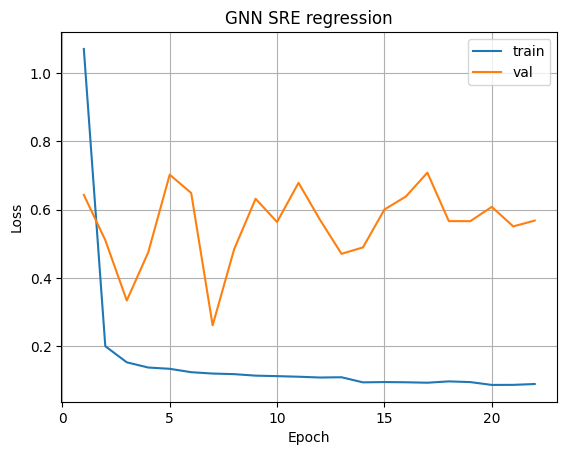

Saved model checkpoint to %s ..\models\gnn_model_mse_random.pt


In [ ]:
# GlobalMLP hidden_dim=128, no dropout, mse loss
run(train_config, model_type="gnn", model_params={"hidden_dim": 128, "dropout_rate": 0.1})

# Prediction

In [2]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]


def checkpoint_path(model_kind: str, training_scope: str, family: str | None = None, loss_type: str = "mse") -> Path:
    if model_kind not in {"gnn", "nn"}:
        raise ValueError("model_kind must be 'gnn' or 'nn'")
    if training_scope not in {"global", "family"}:
        raise ValueError("training_scope must be 'global' or 'family'")

    if training_scope == "family":
        if family is None:
            raise ValueError("family must be provided when training_scope='family'")
        return Path(f"models/{model_kind}_model_{loss_type}_{family}.pt")

    return Path(f"models/{model_kind}_model_{loss_type}_global.pt")


def load_checkpoint(path: str | Path) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any]]:
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if not isinstance(payload, dict):
        raise RuntimeError("Checkpoint must be a dict.")

    if "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        model_config = payload.get("model_config", {}) or {}
        feature_config = payload.get("feature_config", {}) or {}
    else:
        # older raw state_dict format
        state_dict = payload
        model_config = {}
        feature_config = {}

    return state_dict, model_config, feature_config


def build_model(model_kind: str, model_config: dict[str, Any]) -> torch.nn.Module:
    if model_kind == "gnn":
        return GNN(
            node_in_dim=int(model_config["node_in_dim"]),
            global_in_dim=int(model_config["global_in_dim"]),
            gnn_hidden=int(model_config.get("gnn_hidden", 32)),
            gnn_heads=int(model_config.get("gnn_heads", 8)),
            global_hidden=int(model_config.get("global_hidden", 16)),
            reg_hidden=int(model_config.get("reg_hidden", 16)),
            num_layers=int(model_config.get("num_layers", 5)),
            dropout_rate=float(model_config.get("dropout_rate", 0.1)),
        )

    if model_kind == "nn":
        return GlobalMLP(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [3]:
class PredictionGraphWrapper:
    def __init__(
        self,
        dataset,
        target_node_dim: int | None = None,
        target_global_dim: int | None = None,
    ):
        self.dataset = dataset
        self.target_node_dim = target_node_dim
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx].clone()

        if self.target_node_dim is not None:
            cur = int(data.x.shape[1])
            if cur < self.target_node_dim:
                data.x = F.pad(data.x, (0, self.target_node_dim - cur))
            elif cur > self.target_node_dim:
                data.x = data.x[:, : self.target_node_dim]

        if hasattr(data, "global_features"):
            g = data.global_features
            if g.dim() > 1:
                g = g.view(-1)

            if self.target_global_dim is not None:
                cur = int(g.shape[0])
                if cur < self.target_global_dim:
                    g = F.pad(g, (0, self.target_global_dim - cur))
                elif cur > self.target_global_dim:
                    g = g[: self.target_global_dim]

            data.global_features = g

        return data


class PredictionTensorWrapper:
    def __init__(self, dataset, target_global_dim: int | None = None):
        self.dataset = dataset
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]
        g = data.global_features
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.target_global_dim is not None:
            cur = int(g.shape[0])
            if cur < self.target_global_dim:
                g = F.pad(g, (0, self.target_global_dim - cur))
            elif cur > self.target_global_dim:
                g = g[: self.target_global_dim]

        meta = getattr(data, "meta", {}) or {}
        target = extract_target_value(data)
        return g, meta, target


def build_prediction_dataset(
    pt_paths: list[str],
    *,
    global_feature_variant: str,
    node_feature_backend_variant: str | None,
    fixed_all_gate_keys: list[str] | None,
):
    return QuantumCircuitGraphDataset(
        root="qqe/cache/prediction_cache",
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_backend_variant,
        fixed_all_gate_keys=fixed_all_gate_keys,
    )


def build_loader(
    model_kind: str,
    dataset,
    *,
    batch_size: int,
    target_node_dim: int | None,
    target_global_dim: int | None,
):
    if model_kind == "gnn":
        wrapped = PredictionGraphWrapper(
            dataset,
            target_node_dim=target_node_dim,
            target_global_dim=target_global_dim,
        )
        return PyGDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    if model_kind == "nn":
        wrapped = PredictionTensorWrapper(dataset, target_global_dim=target_global_dim)

        def collate_fn(batch):
            xs, metas, targets = zip(*batch)
            return torch.stack(xs, dim=0), list(metas), list(targets)

        return TorchDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [4]:
def extract_target_value(sample: Any) -> float | None:
    y = getattr(sample, "y", None)
    if y is None:
        return None

    if torch.is_tensor(y):
        if y.numel() == 0:
            return None
        value = float(y.flatten()[0].item())
    else:
        value = float(y)

    if not np.isfinite(value):
        return None

    return value

@torch.no_grad()
def predict(
    model: torch.nn.Module,
    loader,
    *,
    model_kind: str,
    device: torch.device,
    show_progress: bool = True,
) -> list[dict[str, Any]]:
    model.eval()
    rows: list[dict[str, Any]] = []
    total_batches = len(loader) if hasattr(loader, "__len__") else None

    if model_kind == "gnn":
        for batch in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (gnn)",
            unit="batch",
            disable=not show_progress,
        ):
            samples = batch.to_data_list()
            batch = batch.to(device)
            preds = model(batch).view(-1).cpu().tolist()

            for sample, pred in zip(samples, preds):
                meta = getattr(sample, "meta", {}) or {}
                target = extract_target_value(sample)
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": meta.get("seed"),
                        "n_qubits": meta.get("n_qubits"),
                        "n_layers": meta.get("n_layers"),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    if model_kind == "nn":
        for x, metas, targets in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (nn)",
            unit="batch",
            disable=not show_progress,
        ):
            x = x.to(device)
            preds = model(x).view(-1).cpu().tolist()

            for meta, pred, target in zip(metas, preds, targets):
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": int(meta.get("seed")),
                        "n_qubits": int(meta.get("n_qubits")),
                        "n_layers": int(meta.get("n_layers")),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [5]:
def save_predictions_csv(rows: list[dict[str, Any]], path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = ["cid", "family", "seed", "n_qubits", "n_layers", "target", "prediction", "error"]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return path


def aggregate_mean_std(
    rows: list[dict[str, Any]],
    *,
    x_key: str,
    fixed_key: str | None = None,
    fixed_value: int | None = None,
) -> list[dict[str, Any]]:
    filtered = rows
    if fixed_key is not None and fixed_value is not None:
        filtered = [r for r in rows if int(r[fixed_key]) == int(fixed_value)]

    groups: dict[int, list[float]] = {}
    for r in filtered:
        x = int(r[x_key])
        groups.setdefault(x, []).append(float(r["prediction"]))

    out = []
    for x in sorted(groups):
        vals = np.asarray(groups[x], dtype=float)
        out.append(
            {
                x_key: x,
                "mean": float(vals.mean()),
                "std": float(vals.std(ddof=0)),
                "n": len(vals),
            },
        )
    return out


# =========================================================
# Plotting
# =========================================================

def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        logger.info("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        logger.info("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

In [7]:
# model_path: str = "../models/nn_model_mse_clifford_v1.pt"
# model_path: str = "../models/nn_model_mse_clifford_v2.pt"
model_path: str = "../models/gnn_model_mse_random.pt"

model_kind: str = "gnn"
training_scope: str = "family"
loss_type: str = "mse"
model_family: str | None = "clifford" #"clifford"
dataset_root: str = "../outputs/data"
dataset_family: str | None = "clifford"
batch_size: int = 32
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int | None = 80
plot_n_qubits: int | None = 16
split_by_family: bool = True
show_progress: bool = True

In [8]:
ckpt_path = checkpoint_path(model_kind, training_scope, model_family, loss_type)
print("Loading checkpoint: %s", ckpt_path)
output_csv = f"../outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"


Loading checkpoint: %s models\gnn_model_mse_clifford.pt


In [9]:
ckpt_path = '../models/gnn_model_mse_clifford.pt'

In [10]:
state_dict, model_config, feature_config = load_checkpoint(ckpt_path)

model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
pt_paths = collect_prediction_paths(dataset_root, dataset_family)
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

print("Found %d prediction files", len(pt_paths))

dataset = build_prediction_dataset(
        pt_paths,
        global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
        node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
        fixed_all_gate_keys=feature_config.get("all_gate_keys"),
    )

loader = build_loader(
        model_kind,
        dataset,
        batch_size=batch_size,
        target_node_dim=model_config.get("node_in_dim"),
        target_global_dim=model_config.get("global_in_dim"),
    )

Found %d prediction files 25000


In [ ]:
rows = predict(
        model,
        loader,
        model_kind=model_kind,
        device=device,
        show_progress=show_progress,
    )
save_predictions_csv(rows, output_csv)

Predicting (gnn): 100%|██████████| 2344/2344 [09:15<00:00,  4.22batch/s]


WindowsPath('../outputs/figures/predictions/family/gnn_predictions_random.csv')

: 

: 

: 

In [12]:
import pandas as pd

In [ ]:
print(rows[:5])

NameError: name 'rows' is not defined

: 

: 

: 

In [ ]:
df = pd.read_csv("../outputs/figures/predictions/family/nn_predictions_random.csv")

: 

: 

: 